# Import

In [1]:
import pandas as pd 

from pymongo import MongoClient 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA


In [2]:
import os
import joblib

# Connection à la BDD

In [ ]:
client = MongoClient("mongodb://localhost:27017/") 

db = client["test"] 

collection = db["tweets"] 

print("Connexion OK à MongoDB") 

# Extraction des données

In [ ]:
pipeline = [
    {"$sample": {"size": 1000000}},
    {
        "$match": {
            "user.id": {"$exists": True, "$ne": None}
        }
    },
    {
        "$group": {
            "_id": "$user.id",

            # Nombre de tweets dans le dataset
            "total_tweets_dataset": {"$sum": 1},

            # Nombre de retweets
            "nb_retweets": {
                "$sum": {
                    "$cond": [
                        {"$ifNull": ["$retweeted_status", False]},
                        1,
                        0
                    ]
                }
            },

            # Nombre total de mentions
            "nb_mentions": {
                "$sum": {
                    "$size": {
                        "$ifNull": ["$entities.user_mentions", []]
                    }
                }
            },

            # Nombre total de hashtags
            "nb_hashtags": {
                "$sum": {
                    "$size": {
                        "$ifNull": ["$entities.hashtags", []]
                    }
                }
            },

            # Nombre total d'URLs
            "nb_urls": {
                "$sum": {
                    "$size": {
                        "$ifNull": ["$entities.urls", []]
                    }
                }
            },

            # Sources utilisées
            "sources": {"$addToSet": "$source"},

            # Dates des tweets
            "first_tweet": {"$min": "$created_at"},
            "last_tweet": {"$max": "$created_at"},

            # Infos utilisateur
            "followers_count": {"$first": "$user.followers_count"},
            "friends_count": {"$first": "$user.friends_count"},
            "statuses_count": {"$first": "$user.statuses_count"},
            "user_created_at": {"$first": "$user.created_at"}
        }
    },
    {
        "$match": {
            "total_tweets_dataset": {"$gt": 5}
        }
    }
]

result = list(collection.aggregate(pipeline, allowDiskUse=True))
df = pd.DataFrame(result)


## Sauvegarde des données

In [ ]:
# 3. Sauvegarde ultra rapide en Parquet
os.makedirs("cache_features", exist_ok=True)
parquet_path = "cache_features/user_features_sample_2.parquet"

df.to_parquet(parquet_path, index=False)

print(f"Fichier Parquet sauvegardé : {parquet_path}")
print(f"Nombre d'utilisateurs stockés : {len(df)}")


## Chargement des données

In [4]:
parquet_path = "cache_features/user_features_sample_2.parquet"

if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
    print("Features chargées depuis le cache Parquet.")
else:
    print("Cache absent : relancer la pipeline.")

Features chargées depuis le cache Parquet.


# Travail sur les variables

In [6]:
# Calcul Taux de Retweet :
df["taux_rt"] = (
    df["nb_retweets"] /
    df["total_tweets_dataset"]
)

# Calcul Intensité :
df["avg_mentions"] = (
    df["nb_mentions"] /
    df["total_tweets_dataset"]
)

df["avg_hashtags"] = (
    df["nb_hashtags"] /
    df["total_tweets_dataset"]
)

df["avg_urls"] = (
    df["nb_urls"] /
    df["total_tweets_dataset"]
)

df["intensite"] = (
    df["avg_mentions"] +
    df["avg_hashtags"] +
    df["avg_urls"]
)

# Nombre de sources différentes
df["nb_sources"] = df["sources"].apply(len)

# Ratio de réputation
df["reputation_ratio"] = (
    df["followers_count"] /
    df["friends_count"].replace(0, np.nan)
)


# Fréquence de publication:
df["first_tweet"] = pd.to_datetime(df["first_tweet"])
df["last_tweet"] = pd.to_datetime(df["last_tweet"])

df["observation_days"] = (
    (df["last_tweet"] - df["first_tweet"])
    .dt.total_seconds()
    / 86400
)

# Éviter les divisions par 0
df["observation_days"] = df["observation_days"].clip(lower=1)

df["tweet_frequency"] = (
    df["total_tweets_dataset"] /
    df["observation_days"]
)

C:\Users\chiva\AppData\Local\Temp\ipykernel_33948\1226650562.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["first_tweet"] = pd.to_datetime(df["first_tweet"])
C:\Users\chiva\AppData\Local\Temp\ipykernel_33948\1226650562.py:41: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["last_tweet"] = pd.to_datetime(df["last_tweet"])


In [11]:
features = [
    "taux_rt",
    "avg_mentions",
    "avg_hashtags",
    "avg_urls",
    "nb_sources",
    "reputation_ratio",
    "tweet_frequency"
]

df_ml = df.copy()

df_ml = df_ml.dropna(subset=features)

# Machine learning non supervisé

In [12]:
X = df_ml[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

df_ml["cluster"] = gmm.fit_predict(X_scaled)

# Probabilité d'appartenance au cluster choisi
proba = gmm.predict_proba(X_scaled)
df_ml["cluster_proba"] = proba.max(axis=1)

# Score d'anomalie : plus c'est bas, plus c'est atypique
df_ml["log_likelihood"] = gmm.score_samples(X_scaled)

In [14]:
summary = df_ml.groupby("cluster")[features].mean()
counts = df_ml["cluster"].value_counts()

print("Nombre d'utilisateurs par cluster :")
print(counts)

print("\nMoyenne des variables par cluster :")
print(summary)

Nombre d'utilisateurs par cluster :
cluster
0    12863
1     3597
2      799
Name: count, dtype: int64

Moyenne des variables par cluster :
          taux_rt  avg_mentions  avg_hashtags  avg_urls  nb_sources  \
cluster                                                               
0        0.664909      0.852309      1.687101  0.150769    1.155018   
1        0.383657      0.540998      2.486078  0.543116    1.665277   
2        0.282258      1.160337      2.145697  0.582028    1.750939   

         reputation_ratio  tweet_frequency  
cluster                                     
0                2.640431         8.086776  
1                9.482883        19.191752  
2            16095.806714        14.748584  


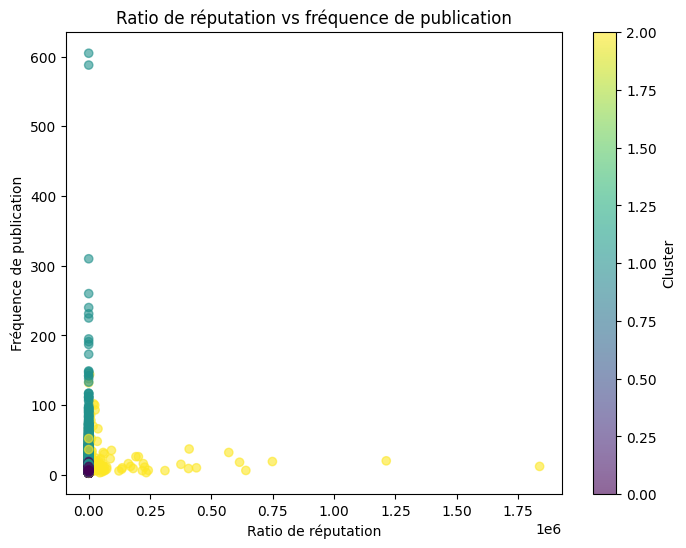

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_ml["reputation_ratio"],
    df_ml["tweet_frequency"],
    c=df_ml["cluster"],
    alpha=0.6
)

plt.xlabel("Ratio de réputation")
plt.ylabel("Fréquence de publication")
plt.title("Ratio de réputation vs fréquence de publication")
plt.colorbar(label="Cluster")
plt.show()

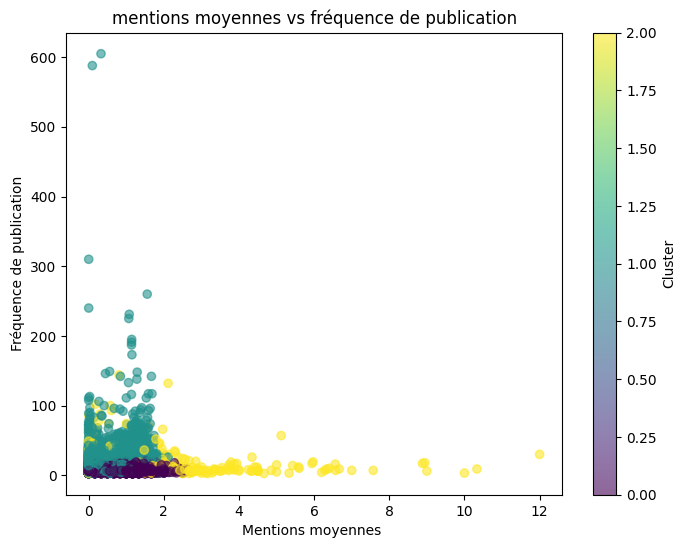

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_ml["avg_mentions"],
    df_ml["tweet_frequency"],
    c=df_ml["cluster"],
    alpha=0.6
)

plt.xlabel("Mentions moyennes ")
plt.ylabel("Fréquence de publication")
plt.title("mentions moyennes vs fréquence de publication")
plt.colorbar(label="Cluster")
plt.show()

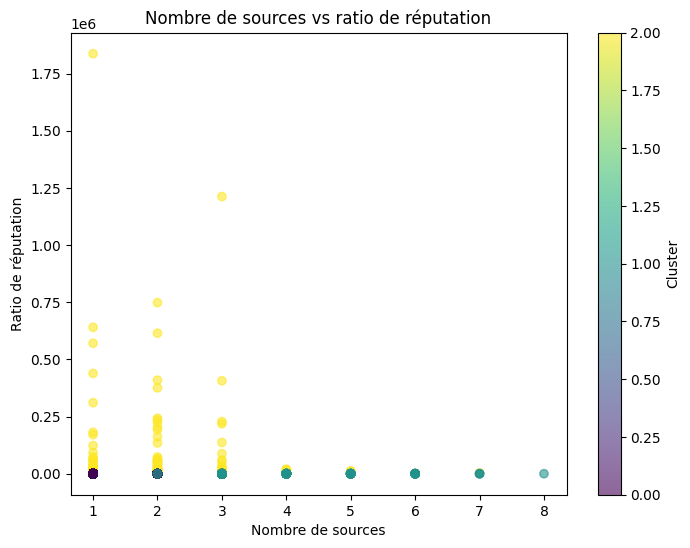

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(
    df_ml["nb_sources"],
    df_ml["reputation_ratio"],
    c=df_ml["cluster"],
    alpha=0.6
)

plt.xlabel("Nombre de sources")
plt.ylabel("Ratio de réputation")
plt.title("Nombre de sources vs ratio de réputation")
plt.colorbar(label="Cluster")
plt.show()